In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [2]:
fake = pd.read_csv("dataset/Fake.csv")
real = pd.read_csv("dataset/True.csv")

In [3]:
fake.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [4]:
real.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [5]:
print("Fake News Shape:", fake.shape)
print("Real News Shape:", real.shape)

Fake News Shape: (23481, 4)
Real News Shape: (21417, 4)


In [6]:
fake.isnull().sum()

title      0
text       0
subject    0
date       0
dtype: int64

In [7]:
real.isnull().sum()

title      0
text       0
subject    0
date       0
dtype: int64

In [8]:
fake["label"] = 0
real["label"] = 1

In [9]:
df = pd.concat([fake, real])

In [10]:
df.shape

(44898, 5)

In [11]:
df = df.sample(frac=1, random_state=42)

df.reset_index(drop=True, inplace=True)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44898 non-null  object
 1   text     44898 non-null  object
 2   subject  44898 non-null  object
 3   date     44898 non-null  object
 4   label    44898 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 1.7+ MB


In [13]:
df["label"].value_counts()

label
0    23481
1    21417
Name: count, dtype: int64

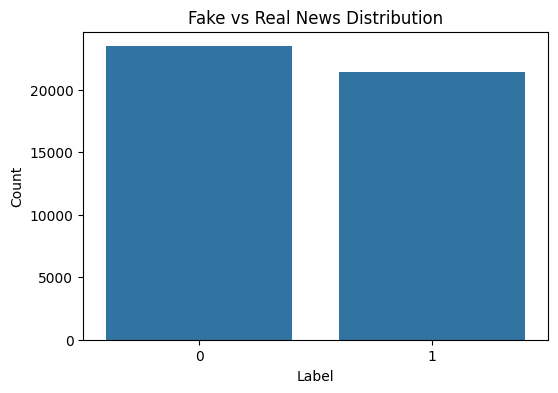

In [14]:
plt.figure(figsize=(6,4))

sns.countplot(x="label", data=df)

plt.title("Fake vs Real News Distribution")
plt.xlabel("Label")
plt.ylabel("Count")

plt.show()

In [15]:
df["length"] = df["text"].apply(len)

In [16]:
df["length"].describe()

count    44898.000000
mean      2469.109693
std       2171.617091
min          1.000000
25%       1234.000000
50%       2186.000000
75%       3105.000000
max      51794.000000
Name: length, dtype: float64

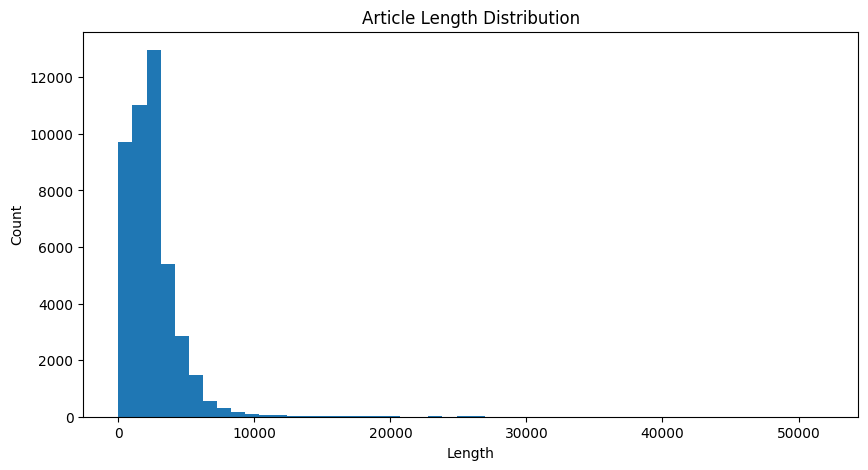

In [17]:
plt.figure(figsize=(10,5))

plt.hist(df["length"], bins=50)

plt.title("Article Length Distribution")
plt.xlabel("Length")
plt.ylabel("Count")

plt.show()

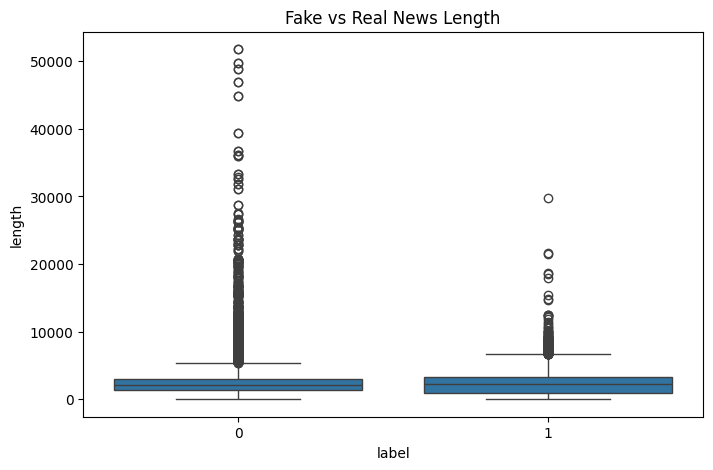

In [18]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="label",
    y="length",
    data=df
)

plt.title("Fake vs Real News Length")

plt.show()

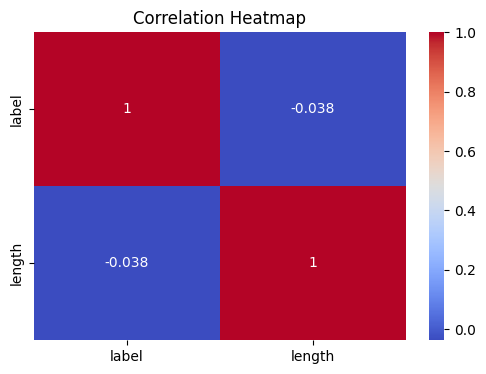

In [19]:
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(6,4))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [20]:
plt.savefig("screenshots/class_distribution.png")

<Figure size 640x480 with 0 Axes>

In [21]:
!pip install wordcloud
from wordcloud import WordCloud

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


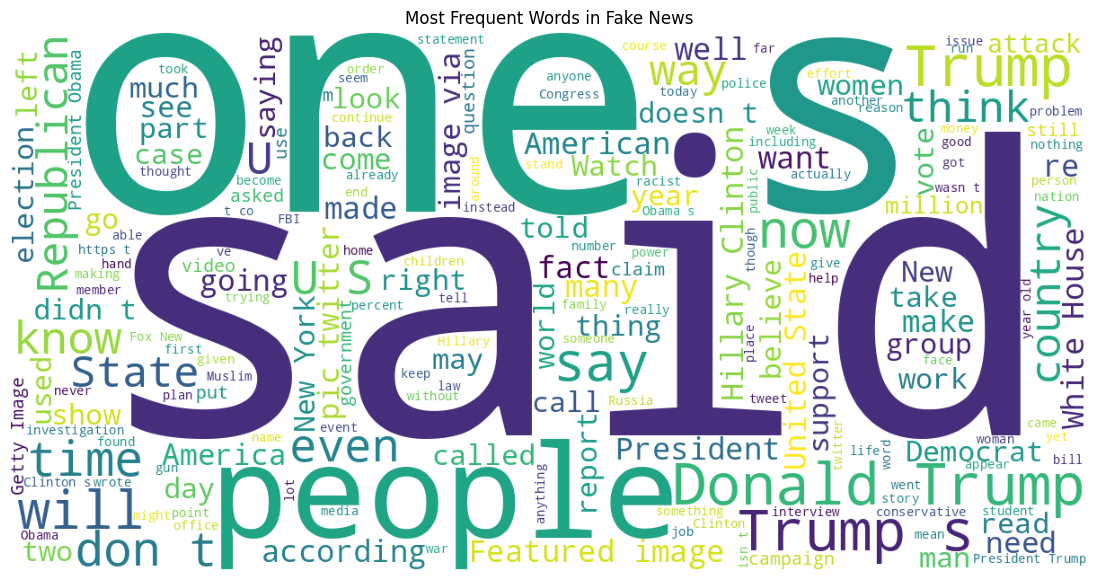

In [22]:
fake_text = " ".join(
    df[df["label"] == 0]["text"]
)

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white"
).generate(fake_text)

plt.figure(figsize=(15,7))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Most Frequent Words in Fake News")
plt.show()

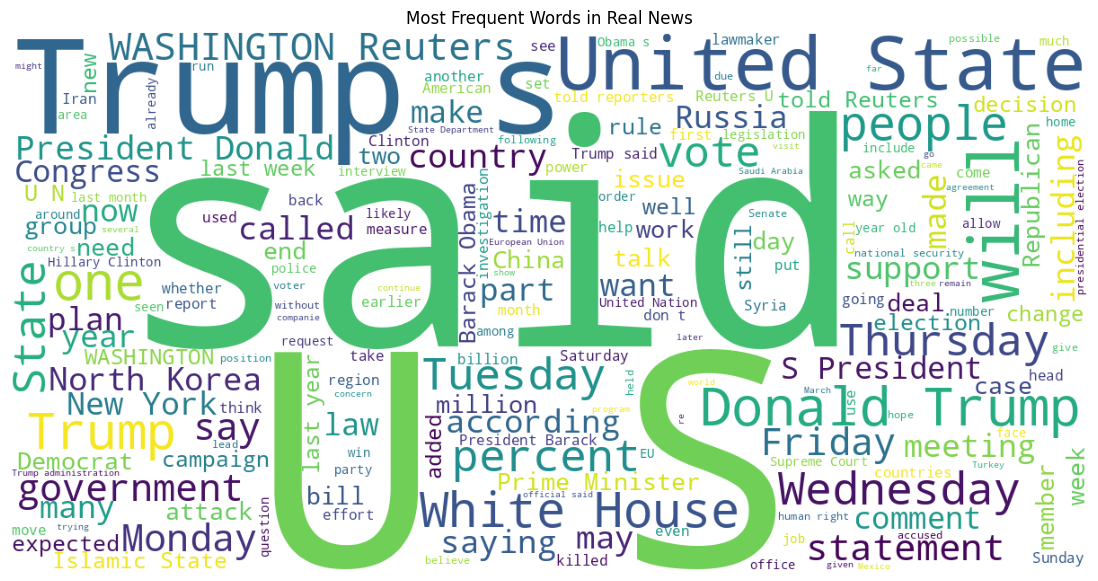

In [23]:
real_text = " ".join(
    df[df["label"] == 1]["text"]
)

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white"
).generate(real_text)

plt.figure(figsize=(15,7))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Most Frequent Words in Real News")
plt.show()

In [24]:
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import re

stemmer = PorterStemmer()
stop_words = set(stopwords.words("english"))

def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)

    words = text.split()

    words = [
        stemmer.stem(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

In [25]:
sample = "The students are playing cricket in the ground."

print(preprocess(sample))

student play cricket ground


In [26]:
df["clean_text"] = df["text"].apply(preprocess)

In [27]:
df[["text","clean_text"]].head()

,text,clean_text
0,"21st Century Wire says Ben Stein, reputable pr...",st centuri wire say ben stein reput professor ...
1,WASHINGTON (Reuters) - U.S. President Donald T...,washington reuter u presid donald trump remov ...
2,(Reuters) - Puerto Rico Governor Ricardo Rosse...,reuter puerto rico governor ricardo rossello s...
3,"On Monday, Donald Trump once again embarrassed...",monday donald trump embarrass countri accident...
4,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",glasgow scotland reuter u presidenti candid go...


In [28]:
X = df["clean_text"]

y = df["label"]

In [29]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [30]:
tfidf = TfidfVectorizer(max_features=5000)

In [31]:
X = tfidf.fit_transform(X)
X.shape

(44898, 5000)

In [32]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [33]:
print(X_train.shape)
print(X_test.shape)

(35918, 5000)
(8980, 5000)


In [34]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [35]:
from sklearn.metrics import accuracy_score

lr_accuracy = accuracy_score(
    y_test,
    y_pred_lr
)

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.9846325167037862


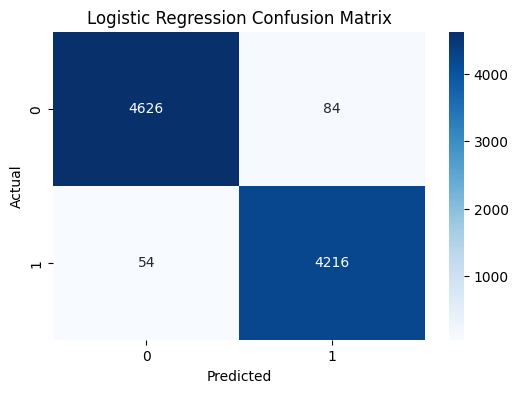

In [36]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred_lr
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [37]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_lr
    )
)

              precision    recall  f1-score   support

           0       0.99      0.98      0.99      4710
           1       0.98      0.99      0.98      4270

    accuracy                           0.98      8980
   macro avg       0.98      0.98      0.98      8980
weighted avg       0.98      0.98      0.98      8980



In [38]:
import pickle

pickle.dump(
    lr,
    open("models/fake_news_model.pkl", "wb")
)

print("Model Saved Successfully")

Model Saved Successfully


In [39]:
sample_news = """
Scientists discover a new planet outside the solar system.
"""

sample_news = preprocess(sample_news)

sample_news = tfidf.transform([sample_news])

prediction = lr.predict(sample_news)

if prediction[0] == 1:
    print("Real News")
else:
    print("Fake News")

Fake News


In [40]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

nb = MultinomialNB()

nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)

nb_accuracy = accuracy_score(y_test, y_pred_nb)

print("Naive Bayes Accuracy:", nb_accuracy)

Naive Bayes Accuracy: 0.925501113585746


In [41]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

rf_accuracy = accuracy_score(
    y_test,
    y_pred_rf
)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.9971046770601336


In [42]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

svm = LinearSVC()

svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

svm_accuracy = accuracy_score(
    y_test,
    y_pred_svm
)

print("SVM Accuracy:", svm_accuracy)

SVM Accuracy: 0.9930957683741648


In [43]:
models = [
    "Logistic Regression",
    "Naive Bayes",
    "Random Forest",
    "SVM"
]

accuracies = [
    lr_accuracy,
    nb_accuracy,
    rf_accuracy,
    svm_accuracy
]

comparison = pd.DataFrame({
    "Model": models,
    "Accuracy": accuracies
})

comparison

,Model,Accuracy
0,Logistic Regression,0.984633
1,Naive Bayes,0.925501
2,Random Forest,0.997105
3,SVM,0.993096


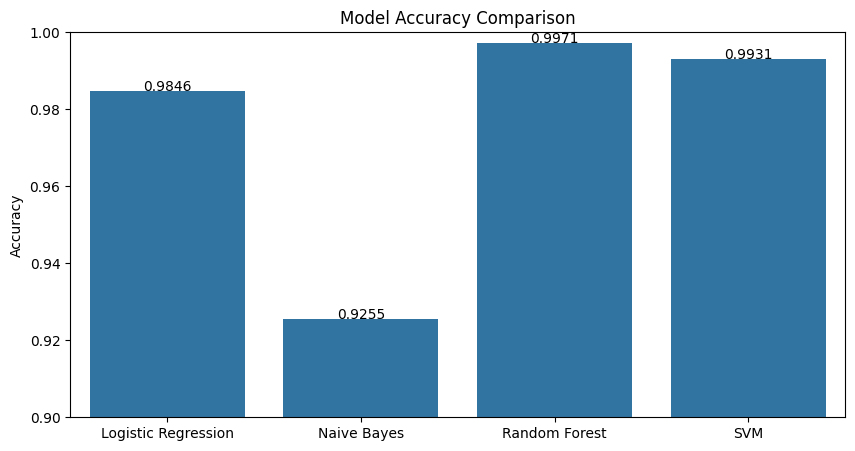

In [47]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=models,
    y=accuracies
)

plt.ylim(0.9, 1.0)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")

for i, acc in enumerate(accuracies):
    plt.text(i, acc, f"{acc:.4f}", ha='center')

plt.show()

In [50]:
import pickle

pickle.dump(
    rf,
    open("models/fake_news_model.pkl", "wb")
)

pickle.dump(
    tfidf,
    open("models/tfidf_vectorizer.pkl", "wb")
)

print("Model Saved Successfully")

Model Saved Successfully


In [51]:
news = """
Scientists discover a new planet outside our solar system.
"""

news = preprocess(news)

news = tfidf.transform([news])

prediction = svm.predict(news)

if prediction[0] == 1:
    print("Real News")
else:
    print("Fake News")

Fake News


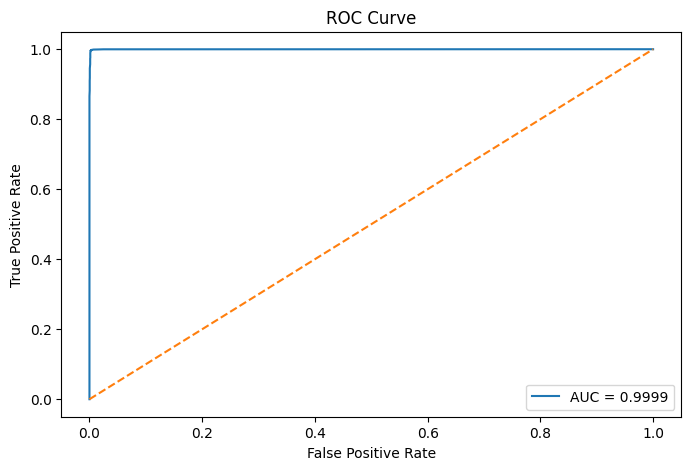

In [52]:
from sklearn.metrics import roc_curve, auc

y_prob = rf.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,5))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [1]:
import os

print("Model Size:",
      os.path.getsize("models/fake_news_model.pkl")/(1024*1024),
      "MB")

print("Vectorizer Size:",
      os.path.getsize("models/tfidf_vectorizer.pkl")/(1024*1024),
      "MB")

Model Size: 27.37789249420166 MB
Vectorizer Size: 0.17158889770507812 MB
